# CONFIGURACION AWS

1. INGRESAR A LA CONSOLA VIA CLI

2. ACCESO A PERSMISOS DE ADMIN: sudo su -l ec2-user

3. CONFIGURAR EL AWS CLI CON LAS CREDENCIALES PREVISTAS

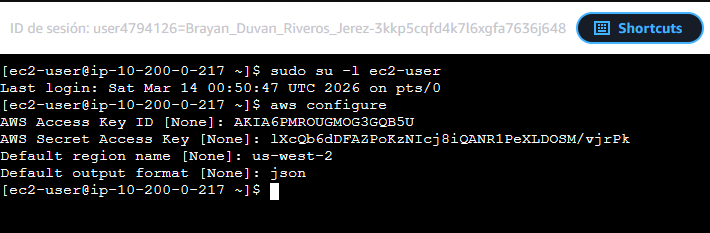


# CREACION BUCKET

1. CREAR EL BUCKET CON EL COMANDO: aws s3api create-bucket --bucket nombreaqui --region us-west-2 --create-bucket-configuration LocationConstraint=us-west-2
SI ES EXITOSO SE GENERARA UN JSON COMO EL SIGUIENTE (recordar que el nombre del bucket debe ser unico):

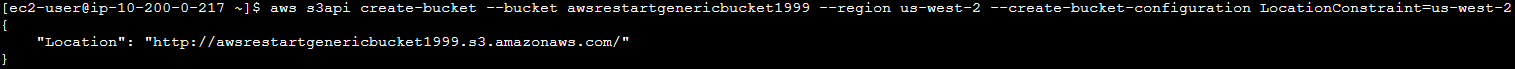


# CREACION DE UN USUARIO CON FULL ACCES A S3 - IAM Y CAMBIO DE PARAMETROS DE BUCKET

1. CREAR USUARIO IAM "awsS3user" CON EL COMANDO: aws iam create-user --user-name awsS3user

2. CREAR SUS CREDENCIALES PARA INICIOS DE SESION: aws iam create-login-profile --user-name awsS3user --password Training123!

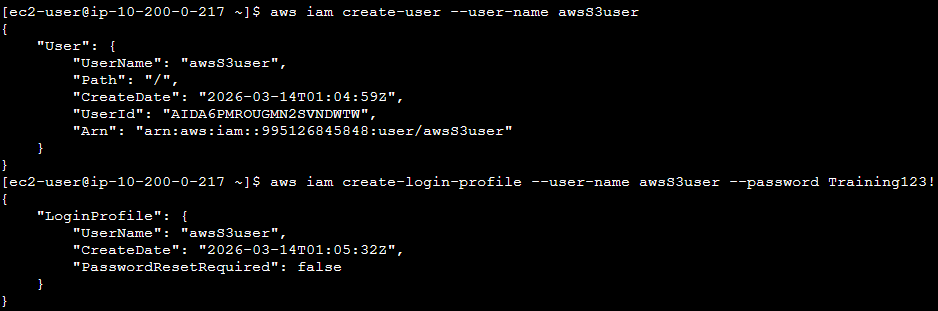

3. INGRESA A LA CONSOLA CON EL USUARIO awsS3user:
    3.1 https://aws.amazon.com/console/
4. TE DARAS DE CUENTA QUE EL SERVICIO S3 AUN NO ES ACCESIBLE DESDE LA CONSOLA.

5. LISTA LAS POLITICAS PARA IDENTIFICAR CUAL BRINDA EL FULL ACCESS A S3 DESDE LA CUENTA MAIN: aws iam list-policies --query "Policies[?contains(PolicyName,'S3')]"

EN ESTE CASO: AmazonS3FullAccess

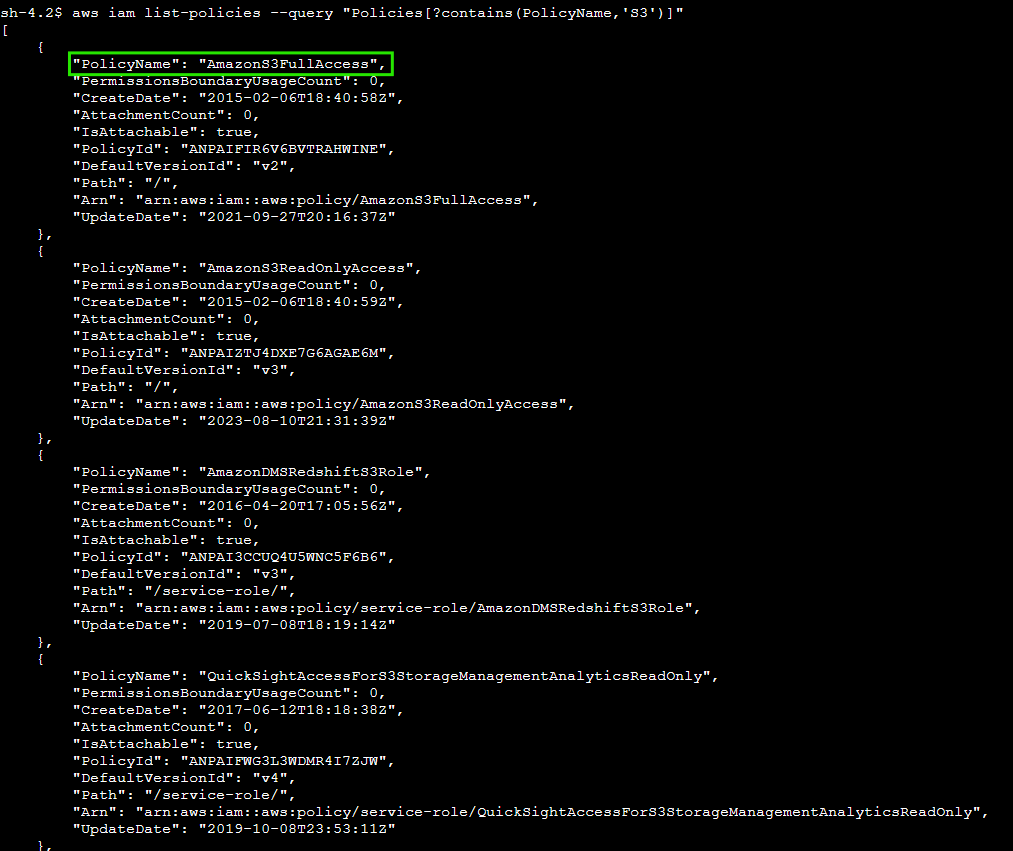

6. BRINDAR ACCESOS EN CLI CON EL USUARIO EC2 CON EL COMANDO: aws iam attach-user-policy --policy-arn arn:aws:iam::aws:policy/AmazonS3FullAccess --user-name awsS3user

7. EN LA CONSOLA DEL USUARIO awsS3user INGRESAR AL BUCKET CREADO Y EN LA PESTAÑA PERMISSION QUITAR EL BLOQUEO AL ACCESO PUBLICO:

ASI DEBE QUEDAR

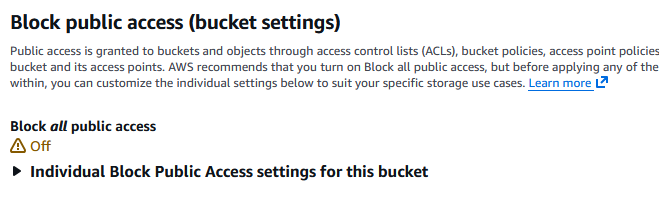

8. EN LA MISMA PESTAÑA DE PERMISOS ACTIVAR LAS ACL'S EN OWNER OWNERSHIP:

ASI DEBE QUEDAR:

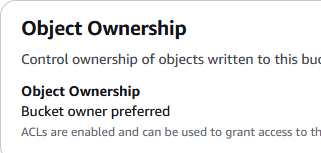

# EXTRACCION Y CARGUE DE ARCHIVOS AL BUCKET

1. NUEVAMENTE EN EL CLI REALIZAR LA EXTRACCION DE LOS DATOS CON EL SCRIPT:
    cd ~/sysops-activity-files
    tar xvzf static-website-v2.tar.gz
    cd static-websit

2. CORRER Ls PARA VALIDAR LOS ARCHIVOS EXTRAIDOS

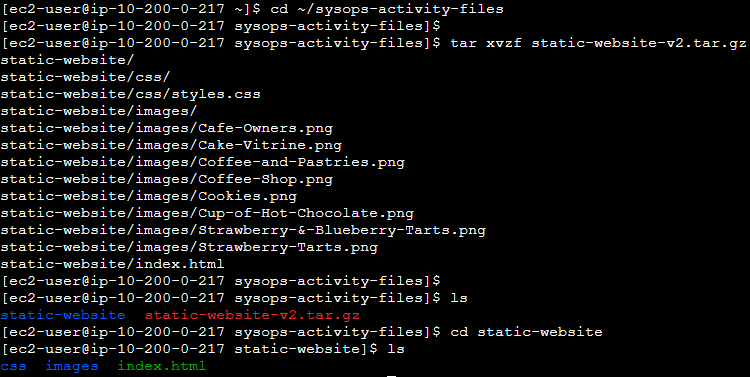

3. USAR EL SIGUIENTE COMANDO PARA IDENTIFICAR EL HTML COMO INDEX: aws s3 website s3://nombrebucketaqui/ --index-document index.html

4. CARGAR EL COTENIDO AL BUCKET PARA LA PAGINA WEB CON EL SIGUIENTE COMANDO: aws s3 cp /home/ec2-user/sysops-activity-files/static-website/ s3://awsrestartgenericbucket1999/ --recursive --acl public-read

5. PARA VERIFICAR QUE LOS ARCHIVOS ESTAN CARGADOS EN EL BUCKET: 

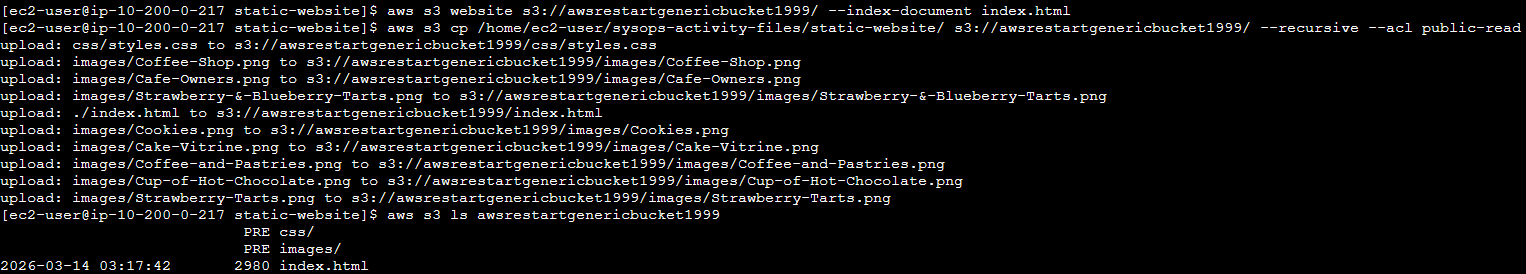

6. FINALMENTE VERFIICAR DESDE LA CONSOLA QUE ESTA HABILITADA LA OPCION DE SITIO WEB ESTATICO EN LA PESTAÑA PROPIEDADES DEL BUCKET:

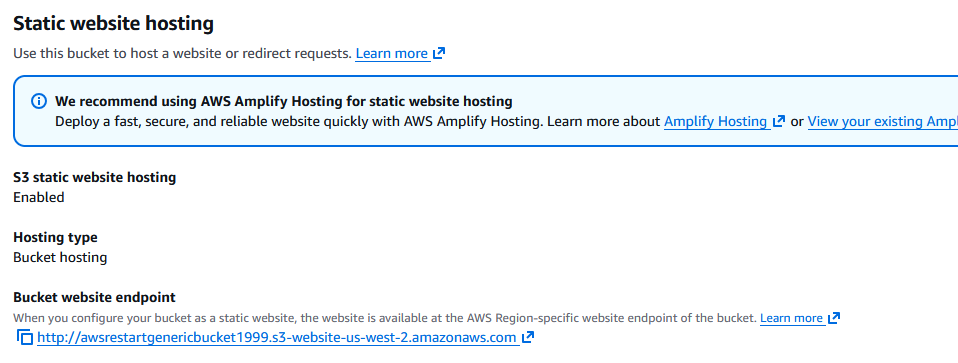

7. VALIDAR QUE SE PUEDE ACCEDER DESDE EL ENDPOINT:

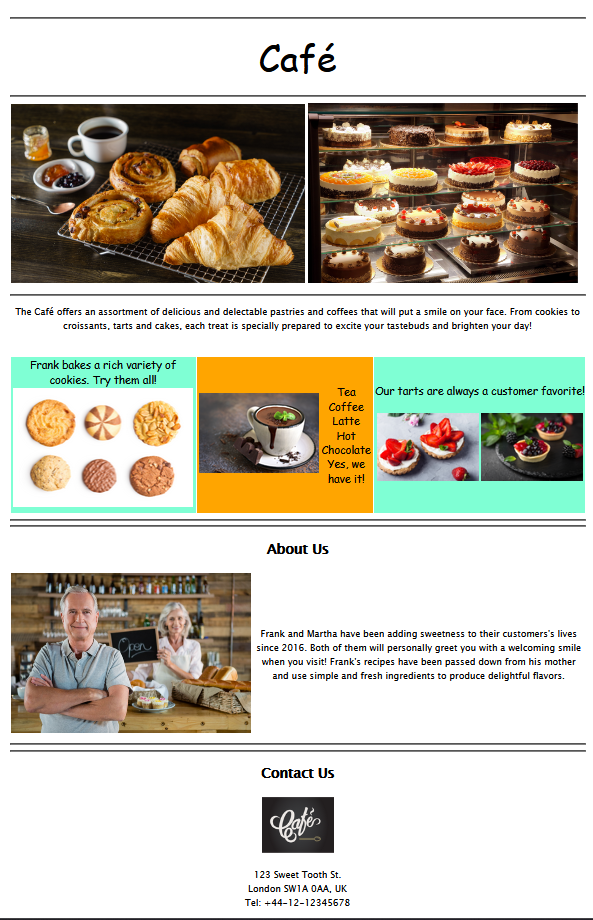

# CREAR UN ARCHIVO BATCH PARA ACTUALIZAR EL SITIO WEB

1. CREAR EL ARCHIVO TOUCH.SH: 
    cd ~
    touch update-website.sh
2. USAR EL EDITOR VIM PARA CREAR EL SCRIPT: vi update-website.sh

RECORDAR CAMBIAR EL BUCKET POR EL NOMBRE REAL

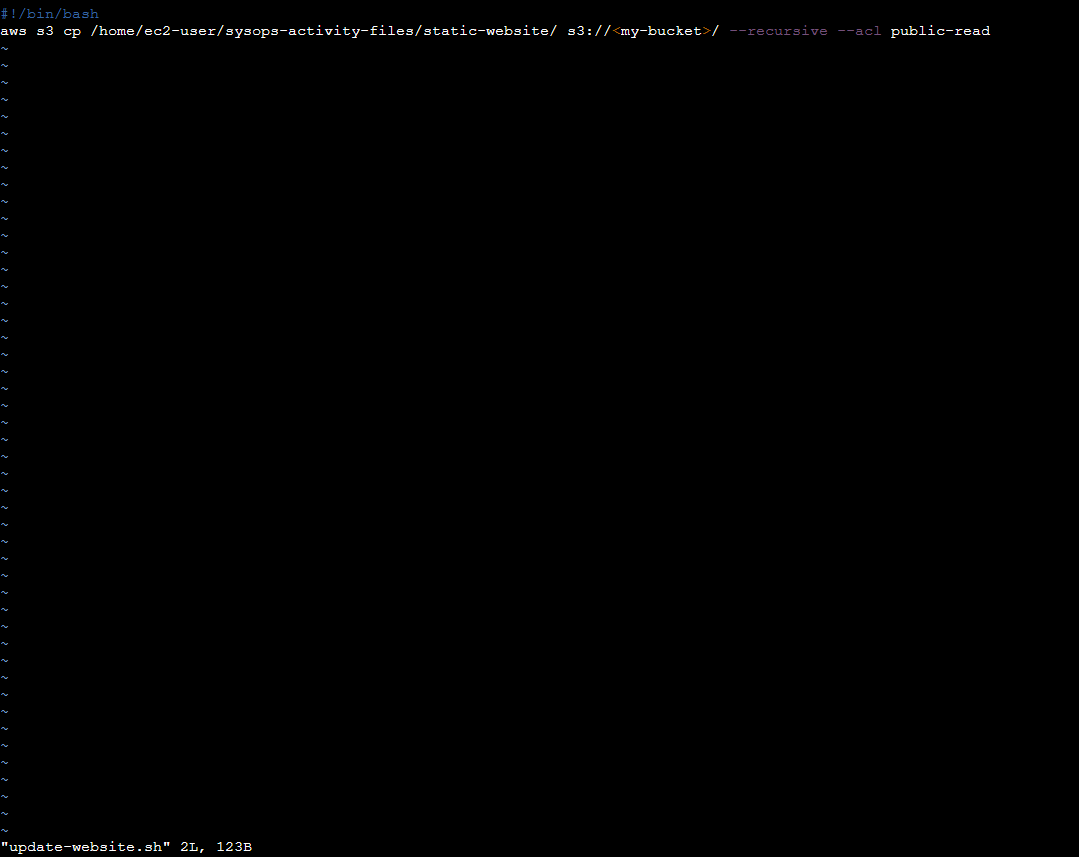

PARA SALIR DEL EDITOR: ESC > :wq

3. CORRER CHMOD PARA HACER EJECUTABLE: chmod +x update-website.sh

4. ABRIR LA COPIA LOCAL DE INDEX Y EDITAR LOS PARAMETROS:
    vi sysops-activity-files/static-website/index.html
    bgcolor="aquamarine" a bgcolor="gainsboro"
    bgcolor="orange" a bgcolor="cornsilk"

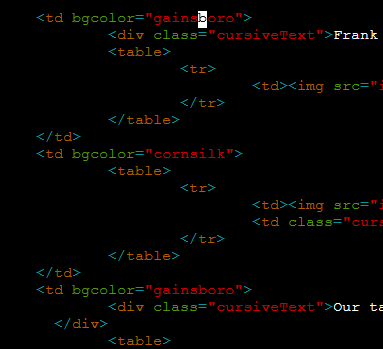

5. PARA ACTUALIZAR EL SITIO BAJO EL SCRIPT FINALMENTE CORRER: ./update-website.sh

PAGINA FINAL CON LOS CAMBIOS REALIZADOS

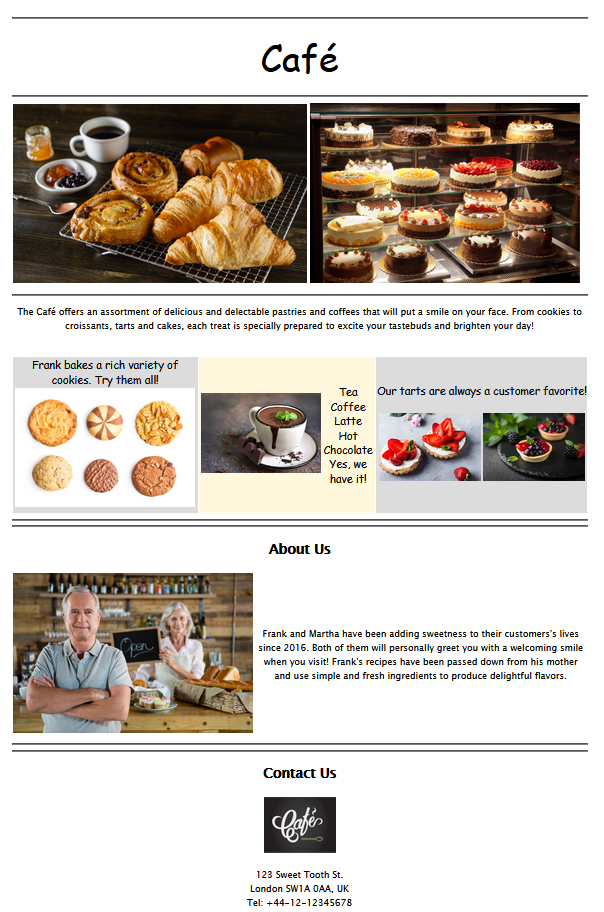

